<a href="https://colab.research.google.com/github/FOFM030711/SIMULACION-II/blob/main/MCMC.%20Algoritmo%20de%20Metropolis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style="color:purple;">**MCMC. Algoritmo de Metropolis**</span>

<span style="color:magenta;"> **Nombre: Jerónimo López Annette Michelle**</span>

<span style="color:teal;"> ***Objetivo:***</span> Simular muestras del vector aleatorio $X = (x₁, x₂)$, cuya densidad $f(x)$ es conocida, usando el algoritmo Metropolis-Hastings con caminata aleatoria. La propuesta es normal simétrica, $Y = Xₜ + Z$ con $Z ∼ N(0, σ²I)$, y el criterio de aceptación es $α = min{\frac{f(Y)}{f(X_t)}, 1}$. Después se verifica que las muestras reproducen la forma de la distribución, comparando su media, mediana y moda con los valores reales.

## <span style="color:purple;">**Algoritmo Metropolis-Hastings**</span>
La idea principal es simular una cadena de Markov tal que su distribución estacionaria coincida con la distribución objetivo.

Suponga que deseamos generar una variable una aleatoria $X$ con valores $x={1,...,m}$ de acuerdo a la distribución ${\pi_i}$, $π_i=\frac{b_i}{C}, i\in x$ suponiendo $b_i$ estrictamente positiva, $m$ grande y la constante de normalización $C=∑_{i=1}^∞ b_i$ dificil de calcular.

Construimos una $CM$ ${X_t,t=0,1,...}$ sobre $x$ cuya evolución esté gobernada por la matriz de transición $Q=q_{ij}$ de La siguiente manera:

* Cuando $X_t=i$, generamos $Y$ que satisfaga $P(Y=j)=q_{i,j}$, $j\in X$

* Si $Y=j$, sea



$j$ con probalidad $α_{i,j}=min\{{\frac{\pi_j q_{ji}}{\pi_i q_{ij}}, 1}\}=min\{{\frac{b_j q_{ji}}{b_i q_{ij}}, 1}\}$

$i$ con probalidad $1-α_{i,j}$


Se sigue entonces que $\{X_t, t=0,1,...\}$ tiene una matriz de transicion de un paso $P=p_{i,j}$ dada por
$$ P_{i,j}=
\begin{cases}
q_{ij} α_{ij} \quad si \quad i\neq j \\
1- \sum _{k\neq i} q_{ik} α_{ik} \quad si \quad i = j
\end{cases}
$$

Y se puede probar (Tarea) que, con $\alpha_{i,j}$ definida arriba,
 * Ecuaciones de balance detallado

 $$\pi_i P_{i,j}=\pi_j P_{j,i}\quad i,j\in X$$
 * Ecuaciones de blance

 $$\pi= \pi P$$


 *Seudocódigo*
 * Dada el estado actual $X_t$
 1. Generar $ Y \sim q(X_t,Y )$
 2. Generar $U∼U(0,1)$ y tomar
  $$ X_{t+1}=
\begin{cases}
Y \quad si \quad U\leq α(X,Y)\\
X_t \quad otro \quad caso
\end{cases}
$$

donde $α(x,y)=min \{ ρ(x,y),1\}$ con $ρ(x,y)=\frac{f(y)q(y,x)}{f(x)q(x,y)}$

**$f(x)$ es la función objetivo**

**$q(x,y)$ es una propuesta (se elije simétrica)**
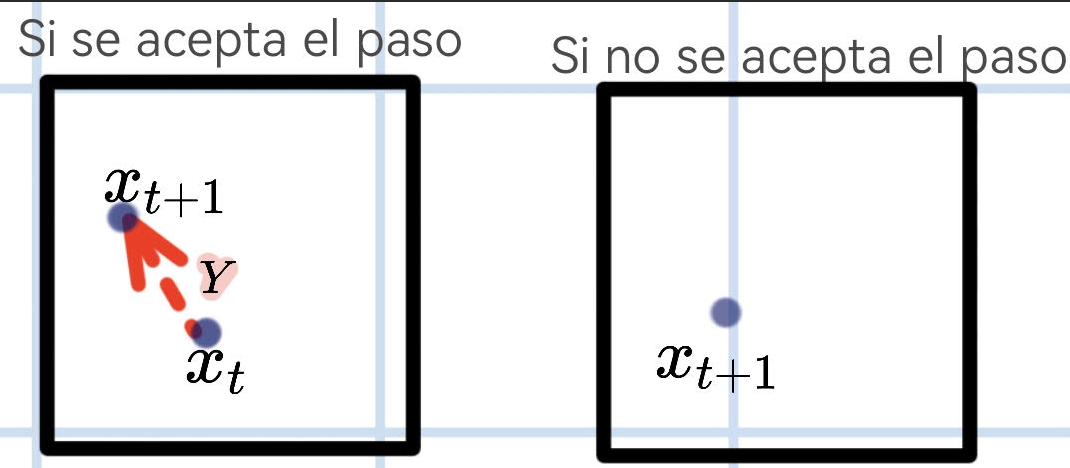


## <span style="color:purple;">**Caminata Aleatoria**</span>
Si se elije $q$ como una $N(0,σ)$, se tiene el sampler más simple, con: $$α(x,y)=min\{\frac{f(y)}{f(x)}, 1\} \quad y \quad Y= x+Z \quad Z∼(N(0,σ),N(0,σ)) $$


* <span style="color:red;">**Ejercicio**: Simular el vector $X=(x_1,x_2)$ que sigue el pdf:</span>

$$f(x)= C*exp (-\frac{x_1^2x_2^2+x_1^2+x_2^2-8x_1-8x_2}{2})$$

$$C=\frac{1}{20216.335877}$$


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# esta librería sirve para resolver
# problemas de optimización matemática y búsqueda de raíces
from scipy import optimize

Definimos la funcion principal:
$$f(x)= C*exp (-\frac{x_1^2x_2^2+x_1^2+x_2^2-8x_1-8x_2}{2})$$

In [ ]:
def densidad_objetivo(x):
    x1, x2 = x
    exponente = -(x1**2 * x2**2 + x1**2 + x2**2 - 8*x1 - 8*x2) / 2
    return np.exp(exponente)

In [ ]:
# Constante de normalización dada en el problema
C = 1 / 20216.335877
C

4.946494785623807e-05

In [ ]:
def f_normalizada(x1, x2): #Normalizamos
    return C * densidad_objetivo([x1, x2])

<span style="color:red;">**PROGRAMA: Metódo Metropoli-Hastings**</span>

*Seudocódigo*
1. Inicialización $X_1=(x_1,x_2).$ Hacer $t=1$
2. Generar $Z_1,Z_2 ∼ N(0,1)$
Sea $Z=Z_1,Z_2$ Y $Y= X_t+Z$
Calcular $α=α(X_t, Y)$
3. Generar $U∼U[0,1]$ sI $U<α.$ Hacer $X_{t+1}=Y$

Otro caso: Hacer $X_{t+1}=X_t$

4. Hacer $t=t+1$. Si $t=N$ (tamaño de la muestra) Detener
Otro caso. Regresar a $2$

In [ ]:
def metropolis_hastings(estado_inicial, num_muestras, desv_propuesta=1.0):
    muestras = np.zeros((num_muestras, 2))
    estado_actual = np.array(estado_inicial)
    muestras[0] = estado_actual

    for t in range(1, num_muestras):
        # Propuesta: Y = X_t + Z, con Z ~ N(0, sigma^2 I)
        paso = np.random.normal(0, desv_propuesta, size=2)
        estado_propuesto = estado_actual + paso

        # Probabilidad de aceptación: alpha = min{ f(Y)/f(X_t), 1 }
        razon = densidad_objetivo(estado_propuesto) / densidad_objetivo(estado_actual)
        alpha = min(1.0, razon)

        # Aceptar o rechazar
        u = np.random.uniform(0, 1)
        if u < alpha:
            estado_actual = estado_propuesto
        muestras[t] = estado_actual

    return muestras

Iniciamos en punto de partida en este caso escogí $ [0,0]$

In [ ]:
estado_inicial = [0.0, 0.0]   # vector inicial
num_muestras = 50000          # número de pasos
desv_propuesta = 1.0          # desviación estándar de la propuesta

In [ ]:
muestras_simuladas = metropolis_hastings(estado_inicial, num_muestras, desv_propuesta)

print("Primeras 5 muestras simuladas:")
print(muestras_simuladas[:5])

Primeras 5 muestras simuladas:
[[ 0.          0.        ]
 [ 0.92485662 -0.25784559]
 [ 0.92485662 -0.25784559]
 [ 0.72983466  0.49712283]
 [ 0.72983466  0.49712283]]


Procedemos a <span style="color:red;">**Graficar los histogramas y el mapa de dispersión**</span> para observar como caen estas simulaciones y como se acerca a la función principal.

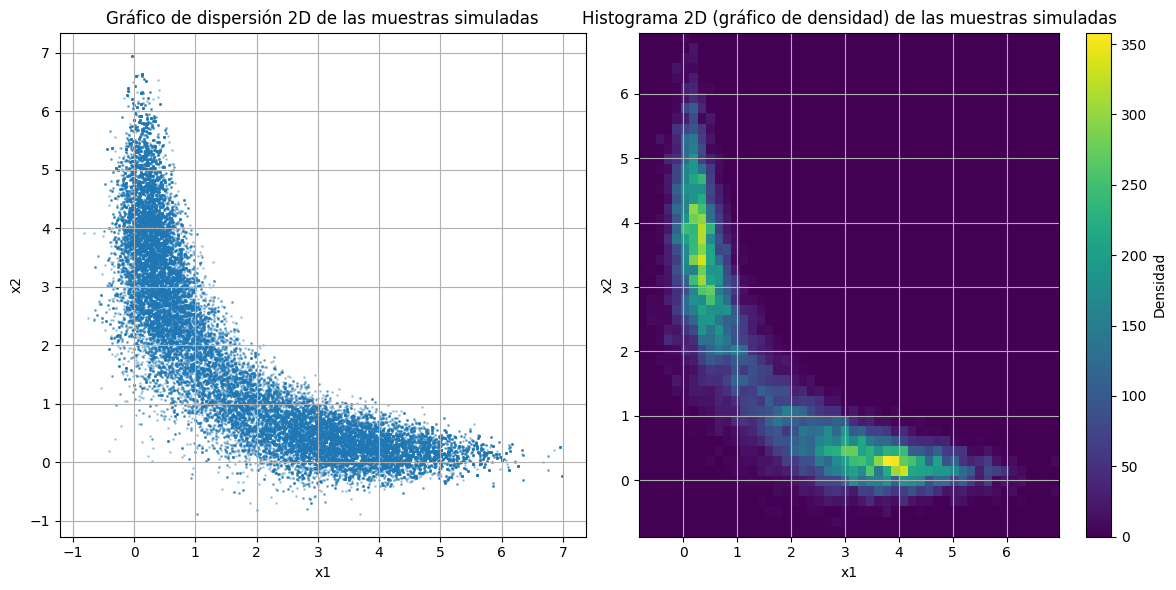

In [ ]:
# Dispersión 2D e histograma 2D
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(muestras_simuladas[:, 0], muestras_simuladas[:, 1], alpha=0.3, s=1)
plt.title('Gráfico de dispersión 2D de las muestras simuladas')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.hist2d(muestras_simuladas[:, 0], muestras_simuladas[:, 1], bins=50, cmap='viridis')
plt.colorbar(label='Densidad')
plt.title('Histograma 2D (gráfico de densidad) de las muestras simuladas')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)

plt.tight_layout()
plt.show()


Observemos que se asemeja aun *platáno* lo cual es muy cercana a la forma real de la función en $2D$

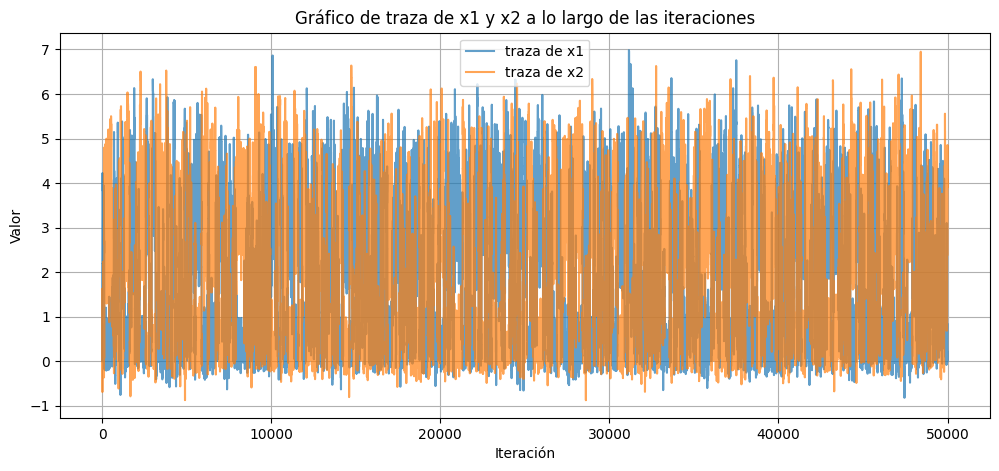

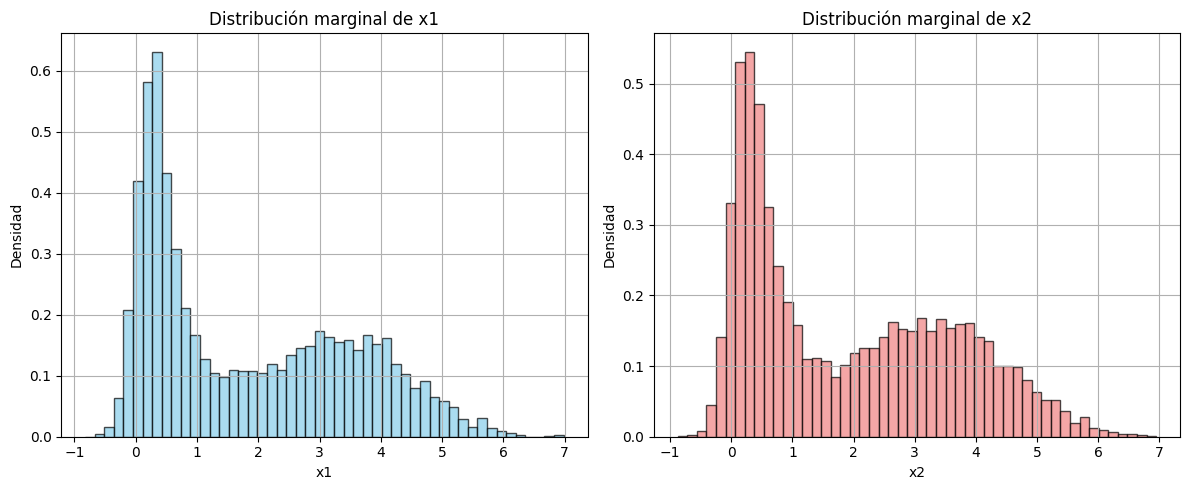

In [ ]:
# Gráfico de traza
plt.figure(figsize=(12, 5))
plt.plot(muestras_simuladas[:, 0], label='traza de x1', alpha=0.7)
plt.plot(muestras_simuladas[:, 1], label='traza de x2', alpha=0.7)
plt.title('Gráfico de traza de x1 y x2 a lo largo de las iteraciones')
plt.xlabel('Iteración')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.show()

# Distribuciones marginales
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(muestras_simuladas[:, 0], bins=50, density=True, alpha=0.7,
         color='skyblue', edgecolor='black')
plt.title('Distribución marginal de x1')
plt.xlabel('x1')
plt.ylabel('Densidad')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.hist(muestras_simuladas[:, 1], bins=50, density=True, alpha=0.7,
         color='lightcoral', edgecolor='black')
plt.title('Distribución marginal de x2')
plt.xlabel('x2')
plt.ylabel('Densidad')
plt.grid(True)

plt.tight_layout()
plt.show()

Con estos histogramas podemos preguntarnos lo siguiente:
* ¿Cuál es la moda?
* ¿Cuál es la mediana?
* ¿Cuál es la media?
Para ello hacemos uso de la librería **from scipy import optimize** Esta librería sirve para resolver problemas de optimización matemática y búsqueda de raíces (aquí la usamos para hallar las modas reales)



In [ ]:
calentamiento = 1000                              # descartamos las primeras muestras (burn-in)
muestras = muestras_simuladas[calentamiento:]

In [ ]:
media = muestras.mean(axis=0)
mediana = np.median(muestras, axis=0)

In [ ]:
# Moda conjunta: celda más alta del histograma 2D
H, xe, ye = np.histogram2d(muestras[:, 0], muestras[:, 1], bins=50)
i, j = np.unravel_index(H.argmax(), H.shape)
moda_conjunta = ((xe[i] + xe[i+1]) / 2, (ye[j] + ye[j+1]) / 2)

In [ ]:
# Moda de cada variable (marginal)
def moda_marginal(v, bins=50):
    h, e = np.histogram(v, bins=bins)
    k = h.argmax()
    return (e[k] + e[k+1]) / 2

In [ ]:
moda_x1 = moda_marginal(muestras[:, 0])
moda_x2 = moda_marginal(muestras[:, 1])

In [ ]:
#Valores reales (integración numérica en una malla)
# ============================================================
g = np.linspace(-6, 12, 3601)
dx = g[1] - g[0]
G1, G2 = np.meshgrid(g, g, indexing='ij')
P = f_normalizada(G1, G2)                         # integra aproximadamente a 1

media_real = np.array([(P * G1).sum(), (P * G2).sum()]) * dx * dx
cdf1 = np.cumsum(P.sum(axis=1)) * dx * dx         # función de distribución marginal de x1
cdf2 = np.cumsum(P.sum(axis=0)) * dx * dx         # función de distribución marginal de x2
mediana_real = np.array([g[np.searchsorted(cdf1, 0.5)],
                         g[np.searchsorted(cdf2, 0.5)]])

# Modas reales (la densidad es bimodal y simétrica entre x1 y x2)
menos_log = lambda x: -np.log(densidad_objetivo(x))
moda_real_A = optimize.minimize(menos_log, [0.0, 3.5]).x
moda_real_B = optimize.minimize(menos_log, [3.5, 0.0]).x

In [ ]:
#Resultados
print(f"\nMuestras usadas simuladas: {len(muestras)}")
print(f"{'':16s}{'x1':>10s}{'x2':>10s}")
print(f"{'Media':16s}{media[0]:10.4f}{media[1]:10.4f}")
print(f"{'Mediana':16s}{mediana[0]:10.4f}{mediana[1]:10.4f}")
print(f"{'Moda (marginal)':16s}{moda_x1:10.4f}{moda_x2:10.4f}")
print(f"Moda conjunta (histograma): ({moda_conjunta[0]:.3f}, {moda_conjunta[1]:.3f})")

print("\nValores reales (integración numérica):")
print(f"Media   = ({media_real[0]:.4f}, {media_real[1]:.4f})")
print(f"Mediana = ({mediana_real[0]:.4f}, {mediana_real[1]:.4f})")
print(f"Modas   = ({moda_real_A[0]:.4f}, {moda_real_A[1]:.4f}) y "
      f"({moda_real_B[0]:.4f}, {moda_real_B[1]:.4f})")


Muestras usadas simuladas: 49000
                        x1        x2
Media               1.8345    1.9026
Mediana             1.2825    1.4265
Moda (marginal)     0.3472    0.2962
Moda conjunta (histograma): (3.782, 0.296)

Valores reales (integración numérica):
Media   = (1.8600, 1.8600)
Mediana = (1.3450, 1.3450)
Modas   = (0.2679, 3.7321) y (3.7321, 0.2679)


Notemos que los valores son casi proximos y que casi el *pega*, pero entre mas simulaciones sean estos valores estarán mas cercanos a los reales.

###<span style="color:teal;">Graficamos la grafica real de la función</span>

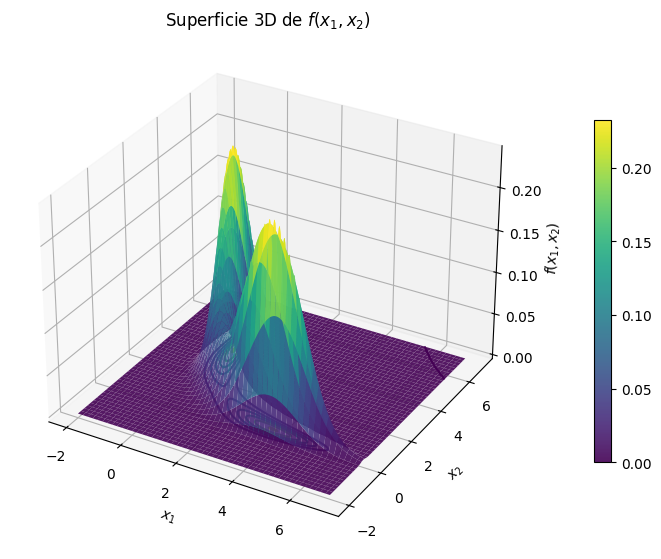

In [ ]:
x1_malla = np.linspace(-2, 7, 250)
x2_malla = np.linspace(-2, 7, 250)
X1, X2 = np.meshgrid(x1_malla, x2_malla)
Z = f_normalizada(X1, X2)

fig = plt.figure(figsize=(14, 6))

ax = fig.add_subplot(1, 2, 1, projection='3d')
superficie = ax.plot_surface(X1, X2, Z, cmap='viridis', edgecolor='none', alpha=0.9)
ax.contour(X1, X2, Z, zdir='z', offset=0, cmap='viridis')   # contornos en la base
ax.set_title('Superficie 3D de $f(x_1,x_2)$')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$f(x_1,x_2)$')
ax.view_init(elev=30, azim=-60)
fig.colorbar(superficie, ax=ax, shrink=0.6, pad=0.1)

plt.tight_layout()
plt.show()

## <span style="color:purple;">**Conlusiones:**</span>

La densidad es bimodal y simétrica entre $x₁$ y $x₂$. La función tiene dos picos, por lo que las dos variables están correlacionadas negativamente: cuando una es grande, la otra es pequeña.

Con varias iteraciones pudimos obervar que, la cadena aceptó cerca del $30 %$ de las propuestas, y las muestras recorren los dos picos y reproducen la forma de $f$. Los valores reales, calculados por integración numérica, son:

* Media: (1.86, 1.86)
* Mediana: (1.345, 1.345)
* Modas: los dos picos de arriba

Mis simulaciones dieron valores muy cercanos, pero pueden variar en cada ejecución.

*Observaciones:*

* La media es mayor que la mediana, lo que indica una distribución sesgada a la derecha.
* La media cae en el valle entre los dos picos, no en una zona de alta densidad. Por eso la moda describe mejor dónde se concentra la probabilidad.

# <span style="color:purple;">**Conlusión:**</span>
El algoritmo Metropolis-Hastings permite simular muestras de una distribución cuando no se pueden generarlas directamente o cuando la constante de normalización es difícil de calcular. Esto es posible porque la probabilidad de aceptación depende solo del cociente $\frac{f(y)}{f(x)}$, y en ese cociente la constante se cancela. El algoritmo construye una cadena de Markov cuya distribución estacionaria es la distribución objetivo.

Las muestras cubrieron las dos zonas de alta densidad, y su media, mediana y moda quedaron cerca de los valores reales calculados por integración numérica. Además, el método resultó fácil de programar y no requirió conocer la constante C.

También quedaron a la vista sus limitaciones. Las muestras consecutivas están correlacionadas, así que la cadena necesita un periodo de calentamiento (burn-in) y muchas iteraciones. La eficiencia depende de la desviación estándar $σ$ de la propuesta: si es muy pequeña, la cadena avanza lento, y si es muy grande, rechaza demasiadas propuestas. En distribuciones con varios picos, como esta, la cadena puede tardar en pasar de uno a otro, y eso afecta la precisión de los estadísticos.